In [1]:
import matplotlib.pyplot
import numpy
import pandas
import scipy
import seaborn

from context import baseline
from context import herd

In [2]:
p = herd.Parameters(SAT=2)
RVs = herd.RandomVariables(p)

# The force of infection implied by the large-population limit of the initial conditions.
P = RVs.initial_conditions.immune_status_pdf._probability
# Integrate over age.
P_total = P.apply(scipy.integrate.trapezoid,
                  args=(P.index,))

force_of_infection_limit = (
    (p.transmission_rate * P_total['infectious']
     + p.chronic_transmission_rate * P_total['chronic'])
    / P_total.sum()
)

force_of_infection_total_limit = (
    force_of_infection_limit
    * (
        P_total['susceptible']
        + p.lost_immunity_susceptibility * P_total['lost_immunity']
    )
    / P_total.sum()
)

force_of_infection_limit, force_of_infection_total_limit

(np.float64(6.971844750383971), np.float64(0.7734456148436128))

In [3]:
SEED = 1
counts_simulation = baseline.run_one(p, SEED, tmax=1, debug=False)

simulation #1 ended after 365 days.


In [4]:
# The force of infection in the simulation.
force_of_infection_simulation = (
    RVs.transmission_rate * counts_simulation['infectious']
    + RVs.chronic_transmission_rate * counts_simulation['chronic']
)

force_of_infection_total_simulation = (
    force_of_infection_simulation
    * (
        counts_simulation['susceptible']
        + p.lost_immunity_susceptibility * counts_simulation['lost_immunity']
    )
    / counts_simulation.sum(axis='columns')
)

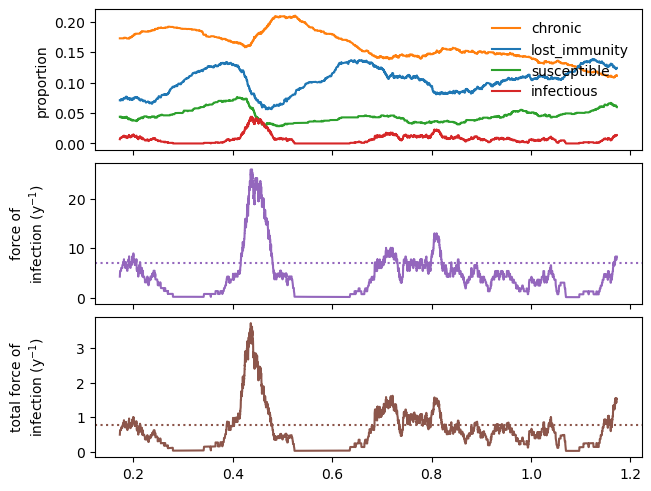

In [5]:
colors = {
    'chronic': 'C1',
    'lost_immunity': 'C0',
    'susceptible': 'C2',
    'infectious': 'C3',
    'force_of_infection': 'C4',
    'force_of_infection_total': 'C5',
}

(fig, axes) = matplotlib.pyplot.subplots(
    3, sharex='col', layout='constrained'
)
proportions_simulation = counts_simulation.div(
    counts_simulation.sum(axis='columns'),
    axis='index'
)
for col in ['chronic', 'lost_immunity', 'susceptible', 'infectious']:
    axes[0].plot(proportions_simulation[col],
                 color=colors[col], label=col)
axes[0].set_ylabel('proportion')
axes[0].legend()
axes[1].plot(force_of_infection_simulation,
             color=colors['force_of_infection'])
axes[1].set_ylabel('force of\ninfection (y$^{-1}$)')
axes[1].axhline(force_of_infection_limit,
                color=colors['force_of_infection'],
                linestyle='dotted', zorder=1)
axes[2].plot(force_of_infection_total_simulation,
             color=colors['force_of_infection_total'])
axes[2].axhline(force_of_infection_total_limit,
                color=colors['force_of_infection_total'],
                linestyle='dotted')
axes[2].set_ylabel('total force of\ninfection (y$^{-1}$)')
fig.align_labels()

In [6]:
# The force of infection from sample initial conditions.
nsamples = 100
force_of_infection_samples = []
force_of_infection_total_samples = []
for _ in range(nsamples):
    sample = RVs.initial_conditions.rvs()
    force_of_infection_samples.append(
        RVs.transmission_rate * len(sample['infectious'])
        + RVs.chronic_transmission_rate * len(sample['chronic'])
    )
    force_of_infection_total_samples.append(
        force_of_infection_samples[-1]
        * (len(sample['susceptible'])
           + p.lost_immunity_susceptibility * len(sample['lost_immunity']))
        / sum(len(v) for v in sample.values())
    )

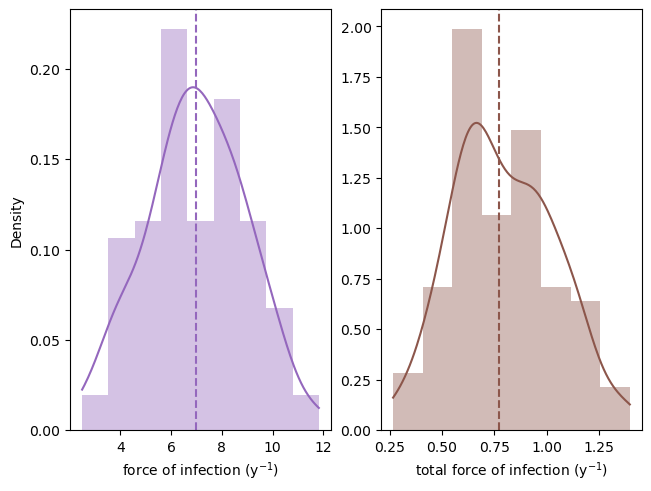

In [7]:
(fig, axes) = matplotlib.pyplot.subplots(
    ncols=2, layout='constrained'
)
seaborn.histplot(force_of_infection_samples,
                 color=colors['force_of_infection'],
                 stat='density', kde=True, kde_kws={'cut': 0},
                 linestyle='None', alpha=0.4, ax=axes[0])
axes[0].axvline(force_of_infection_limit,
                color=colors['force_of_infection'],
                linestyle='dashed')
axes[0].set_xlabel('force of infection (y$^{-1}$)')
seaborn.histplot(force_of_infection_total_samples,
                 color=colors['force_of_infection_total'],
                 stat='density', kde=True, kde_kws={'cut': 0},
                 linestyle='None', alpha=0.4, ax=axes[1])
axes[1].axvline(force_of_infection_total_limit,
                color=colors['force_of_infection_total'],
                linestyle='dashed')
axes[1].set_xlabel('total force of infection (y$^{-1}$)')
axes[1].set_ylabel('')
fig.align_labels()